In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)


X_pima = pima_df[pima_cols[:-1]].copy()
y_pima = pima_df['Outcome']


cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_pima[cols_to_impute] = X_pima[cols_to_impute].replace(0, np.nan)


imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_pima)

scaler = StandardScaler()
X_pima_scaled = scaler.fit_transform(X_imputed)


X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima_scaled, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

print("Preprocessed Pima dataset shapes:")
print(f"  Training set features: {X_train_p.shape} | Test set features: {X_test_p.shape}")

Preprocessed Pima dataset shapes:
  Training set features: (614, 8) | Test set features: (154, 8)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


ann_pima = Sequential([

    Dense(16, activation='relu', input_shape=(8,)),

    Dense(8, activation='relu'),

    Dense(1, activation='sigmoid')
])

print("Sequential ANN Architecture established:")
ann_pima.summary()

Sequential ANN Architecture established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:

ann_pima.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Neural network model compiled successfully.")

Neural network model compiled successfully.


In [4]:
history_pima = ann_pima.fit(
    X_train_p,
    y_train_p,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5438 - loss: 0.7023 - val_accuracy: 0.6016 - val_loss: 0.6816
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6456 - loss: 0.5949 - val_accuracy: 0.6585 - val_loss: 0.5962
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7088 - loss: 0.5386 - val_accuracy: 0.6911 - val_loss: 0.5442
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7352 - loss: 0.5056 - val_accuracy: 0.6992 - val_loss: 0.5161
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7495 - loss: 0.4885 - val_accuracy: 0.7073 - val_loss: 0.4985
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7536 - loss: 0.4779 - val_accuracy: 0.7073 - val_loss: 0.4869
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7617 - loss: 0.4700 - val_accuracy: 0.7398 - val_loss: 0.4810
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7637 - loss: 0.4647 - val_accuracy: 0.7317 - val_loss:

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
ANN Holdout Test Accuracy: 70.78%

--- Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.77      0.78      0.78       100
    Diabetes       0.58      0.57      0.58        54

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



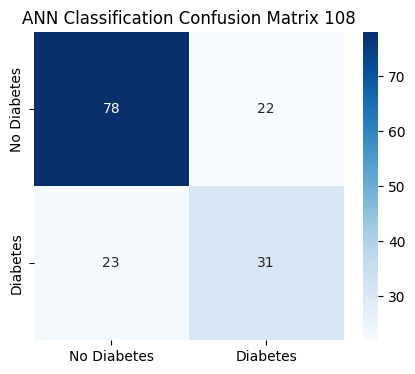

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = ann_pima.predict(X_test_p)

y_pred_classes = (y_pred_probs >= 0.5).astype(int)

test_acc = accuracy_score(y_test_p, y_pred_classes)
print(f"ANN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test_p, y_pred_classes, target_names=['No Diabetes', 'Diabetes']))


cm_pima = confusion_matrix(y_test_p, y_pred_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("ANN Classification Confusion Matrix 108")
plt.show()

In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)


sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']

scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)


X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_sonar = Sequential([

    Dense(64, activation='relu', input_shape=(60,)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

print("Regularized Sonar ANN Architecture established:")
ann_sonar.summary()

Regularized Sonar ANN Architecture established:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:

ann_sonar.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sonar = ann_sonar.fit(
    X_train_s,
    y_train_s,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")

Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.5690 - loss: 0.7814 - val_accuracy: 0.6552 - val_loss: 0.6062
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5517 - loss: 0.7224 - val_accuracy: 0.6552 - val_loss: 0.5533
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5948 - loss: 0.6864 - val_accuracy: 0.7241 - val_loss: 0.5109
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6724 - loss: 0.5518 - val_accuracy: 0.7931 - val_loss: 0.4816
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6379 - loss: 0.5937 - val_accuracy: 0.7931 - val_loss: 0.4575
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7241 - loss: 0.5244 - val_accuracy: 0.7931 - val_loss: 0.4384
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7328 - loss: 0.4886 - val_accuracy: 0.7931 - val_loss: 0.4224
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8017 - loss: 0.4898 - val_accuracy: 0.7931 - val_loss: 0.4147


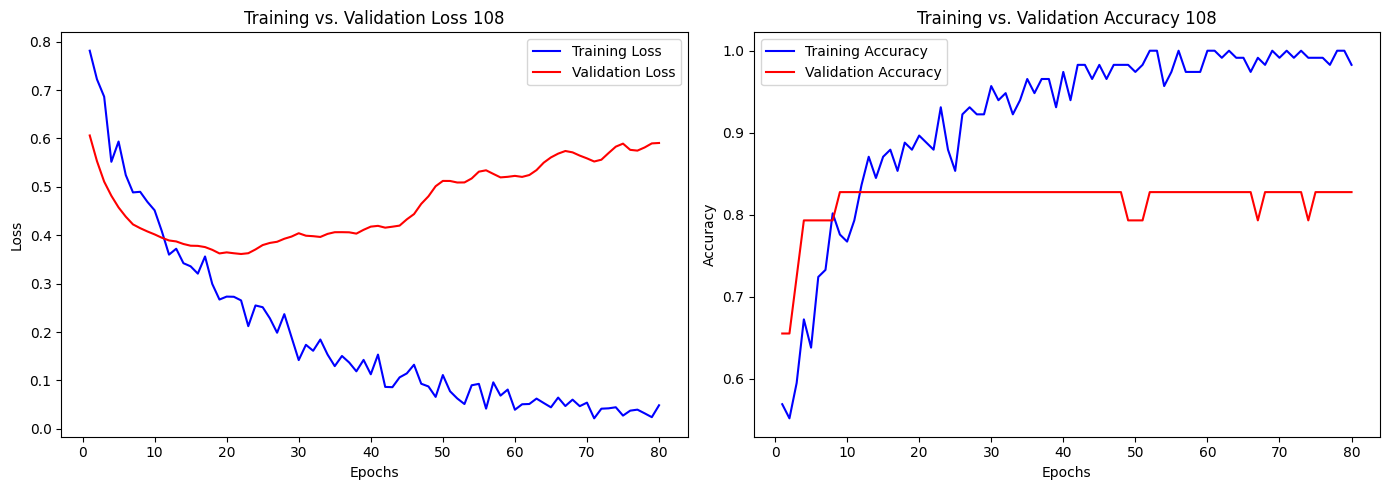

In [17]:
import matplotlib.pyplot as plt

train_loss = history_sonar.history['loss']
val_loss = history_sonar.history['val_loss']
train_acc = history_sonar.history['accuracy']
val_acc = history_sonar.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss, 'b-', label='Training Loss')
axes[0].plot(epochs_range, val_loss, 'r-', label='Validation Loss')
axes[0].set_title("Training vs. Validation Loss 108")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, train_acc, 'b-', label='Training Accuracy')
axes[1].plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
axes[1].set_title("Training vs. Validation Accuracy 108")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
--- Classification Report (Sonar Test Set) ---
              precision    recall  f1-score   support

    Rock (0)       0.81      0.86      0.83        29
    Mine (1)       0.88      0.82      0.85        34

    accuracy                           0.84        63
   macro avg       0.84      0.84      0.84        63
weighted avg       0.84      0.84      0.84        63



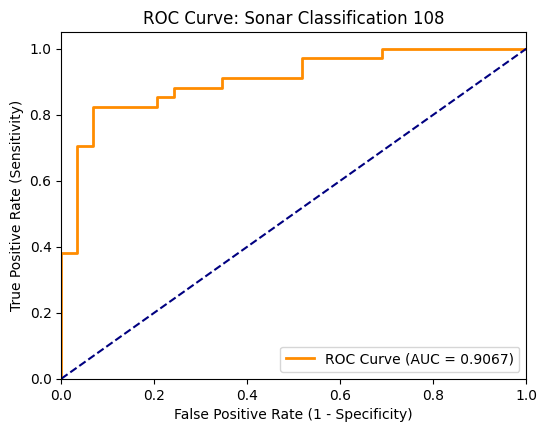

In [16]:
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt


sonar_probs = ann_sonar.predict(X_test_s)[:, 0]
sonar_preds = (sonar_probs >= 0.5).astype(int)


print("--- Classification Report (Sonar Test Set) ---")
print(classification_report(y_test_s, sonar_preds, target_names=['Rock (0)', 'Mine (1)']))

fpr, tpr, _ = roc_curve(y_test_s, sonar_probs)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("ROC Curve: Sonar Classification 108")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.show()

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


def build_ann_model(optimizer_name='adam'):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(8,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer_name,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Modular ANN model builder function established.")

Modular ANN model builder function established.


In [12]:
optimizers = ['adam', 'sgd', 'rmsprop']
history_records = {}

print("--- Running Optimizer Search ---")
for opt in optimizers:
    print(f"Training network using: {opt}...")
    temp_model = build_ann_model(optimizer_name=opt)


    hist = temp_model.fit(
        X_train_p,
        y_train_p,
        validation_split=0.2,
        epochs=30,
        batch_size=16,
        verbose=0
    )
    history_records[opt] = hist.history['loss']

print("Tuning loop complete.")

--- Running Optimizer Search ---
Training network using: adam...
Training network using: sgd...
Training network using: rmsprop...
Tuning loop complete.


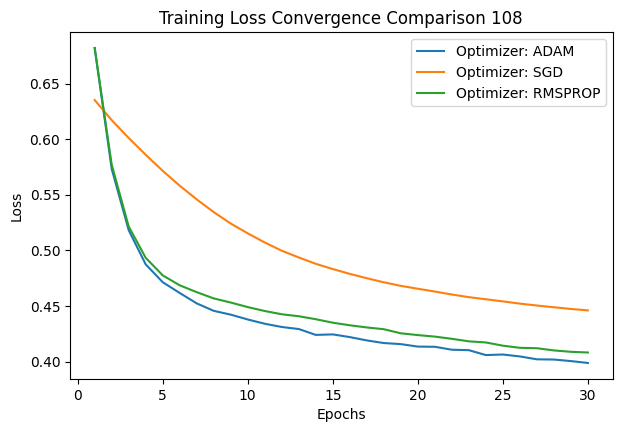

In [15]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4.5))
for opt in optimizers:
    plt.plot(range(1, 31), history_records[opt], label=f"Optimizer: {opt.upper()}")

plt.title("Training Loss Convergence Comparison 108")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [14]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


tuned_model = build_ann_model(optimizer_name='adam')

print("Training model with Early Stopping...")

history_tuned = tuned_model.fit(
    X_train_p,
    y_train_p,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Training model with Early Stopping...
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5540 - loss: 0.6883 - val_accuracy: 0.6911 - val_loss: 0.6357
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7454 - loss: 0.5907 - val_accuracy: 0.7642 - val_loss: 0.5595
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7597 - loss: 0.5255 - val_accuracy: 0.7724 - val_loss: 0.5083
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7699 - loss: 0.4880 - val_accuracy: 0.8049 - val_loss: 0.4788
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7739 - loss: 0.4698 - val_accuracy: 0.8049 - val_loss: 0.4652
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7821 - loss: 0.4563 - val_accuracy: 0.7886 - val_loss: 0.4588
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7821 - loss: 0.4496 - val_accuracy: 0.7805 - val_loss: 0.4524
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7882 - 

In [19]:
from sklearn.metrics import accuracy_score


baseline_accuracy = ann_pima.evaluate(X_test_p, y_test_p, verbose=0)[1]


tuned_accuracy = tuned_model.evaluate(X_test_p, y_test_p, verbose=0)[1]

comparison_df = pd.DataFrame({
    'Model Configuration': ['Baseline ANN (Fixed 50 Epochs)', 'Tuned ANN (with Early Stopping)'],
    'Test Accuracy (%)': [baseline_accuracy * 100, tuned_accuracy * 100],
    'Epochs Trained': [50, len(history_tuned.history['loss'])]
})

print("--- Final Performance Comparison ---")
print(comparison_df.to_string(index=False))

--- Final Performance Comparison ---
            Model Configuration  Test Accuracy (%)  Epochs Trained
 Baseline ANN (Fixed 50 Epochs)          70.779222              50
Tuned ANN (with Early Stopping)          74.675328              22
